In [1]:
import pandas as pd
data = pd.read_csv('processed/all_years_aggregated.csv')


In [14]:
data.shape

(12960, 64)

(array([ 652.,  269.,  753., 2082., 3896., 3177., 1255.,  449.,  153.,
         274.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

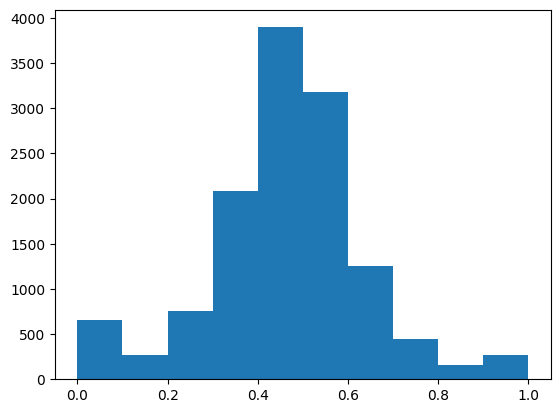

In [13]:
# plotting a histogram of the sex_1 variable
import matplotlib.pyplot as plt
plt.hist(data['sex_1'])

In [30]:
#count the number of times that weight is 0 
print(data[data['weight'] == 0].shape[0])
# showing where the weight is 0
print(data[data['weight'] == 0])

# overall total rows and columns
print(data.shape)
weight_zero_df = data[data['weight'] == 0]
# distribution of the different groups where the weight is 0


268
       geo_region     education_grouped age_group family_income_grouped  year  \
95              1  less_than_highschool     25-34           high_income    10   
100             1  less_than_highschool     35-44           high_income    10   
121             1     masters_and_above     18-24            low_income    10   
122             1     masters_and_above     18-24    lower_middle_class    10   
275             2  less_than_highschool     25-34           high_income    10   
...           ...                   ...       ...                   ...   ...   
12721           8     masters_and_above     18-24            low_income    24   
12722           8     masters_and_above     18-24    lower_middle_class    24   
12723           8     masters_and_above     18-24          middle_class    24   
12902           9     masters_and_above     18-24    lower_middle_class    24   
12903           9     masters_and_above     18-24          middle_class    24   

       weight  time_at_

In [33]:
problematic_groups = (
    weight_zero_df
    .groupby(["education_grouped", "age_group", "family_income_grouped", "geo_region"])
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
)

problematic_groups.head(50)

# clear contratdictions - masters and above 18-24 years olds with low income
# or high income and low education 
# not sure its better to manually filter these out 

,education_grouped,age_group,family_income_grouped,geo_region,count
62,masters_and_above,18-24,low_income,8,6
58,masters_and_above,18-24,low_income,4,6
69,masters_and_above,18-24,lower_middle_class,6,6
18,less_than_highschool,25-34,high_income,6,6
39,less_than_highschool,55-64,high_income,6,5
16,less_than_highschool,25-34,high_income,4,5
49,masters_and_above,18-24,high_income,4,5
67,masters_and_above,18-24,lower_middle_class,4,5
53,masters_and_above,18-24,high_income,8,5
66,masters_and_above,18-24,lower_middle_class,3,5


In [84]:
# creating group ids to track the demographic groups we've created over time 
data["group_id"] = (
    data["geo_region"].astype(str) + "_" +
    data["education_grouped"].astype(str) + "_" +
    data["age_group"].astype(str) + "_" +
    data["family_income_grouped"].astype(str)
)

In [85]:
grouped = data.groupby(["group_id", "year"]).sum()

In [36]:
grouped = grouped.sort_values(["group_id", "year"])
grouped.head()

geo_region education_grouped age_group  \
group_id                       year                                           
1_associates_18-24_high_income 10             1        associates     18-24   
                               12             1        associates     18-24   
                               14             1        associates     18-24   
                               16             1        associates     18-24   
                               18             1        associates     18-24   

                                    family_income_grouped     weight  \
group_id                       year                                    
1_associates_18-24_high_income 10             high_income    6428960   
                               12             high_income   32760596   
                               14             high_income  106149207   
                               16             high_income    9128038   
                               18             high_income   30609392   

                                     time_at_curr_address_-9  \
group_id                       year                            
1_associates_18-24_high_income 10                        0.0   
                               12                        0.0   
                               14                        0.0   
                               16                        0.0   
                               18                        0.0   

                                     time_at_curr_address_-3  \
group_id                       year                            
1_associates_18-24_high_income 10                        0.0   
                               12                        0.0   
                               14                        0.0   
                               16                        0.0   
                               18                        0.0   

                                     time_at_curr_address_-2  \
group_id                       year                            
1_associates_18-24_high_income 10                        0.0   
                               12                        0.0   
                               14                        0.0   
                               16                        0.0   
                               18                        0.0   

                                     time_at_curr_address_1  \
group_id                       year                           
1_associates_18-24_high_income 10                       0.0   
                               12                       0.0   
                               14                       0.0   
                               16                       0.0   
                               18                       0.0   

                                     time_at_curr_address_2  ...     sex_1  \
group_id                       year                          ...             
1_associates_18-24_high_income 10                  0.000000  ...  1.000000   
                               12                  1.000000  ...  1.000000   
                               14                  0.042047  ...  0.532849   
                               16                  0.000000  ...  0.000000   
                               18                  0.000000  ...  0.830138   

                                        sex_2  race_grouped_PI_only  \
group_id                       year                                   
1_associates_18-24_high_income 10    0.000000                   0.0   
                               12    0.000000                   0.0   
                               14    0.467151                   0.0   
                               16    1.000000                   0.0   
                               18    0.169862                   0.0   

                                     race_grouped_american_indian_only  \
group_id                       year                                   

In [37]:
# looking at one group over time for a sanity check 
sample_group = (
    (data["geo_region"] == 1) &
    (data["education_grouped"] == "masters_and_above") &
    (data["age_group"] == "55-64") &
    (data["family_income_grouped"] == "high_income")
)

In [38]:
group_example = data[sample_group]


In [39]:
group_ts = (
    group_example
    .groupby("year")
    .mean(numeric_only=True)
    .reset_index()
    .sort_values("year")
)
print(group_ts[["year", "did_vote_1"]])

   year  did_vote_1
0    10    0.873551
1    12    0.922535
2    14    0.851197
3    16    0.954833
4    18    0.894476
5    20    0.949672
6    22    0.946788
7    24    0.993199


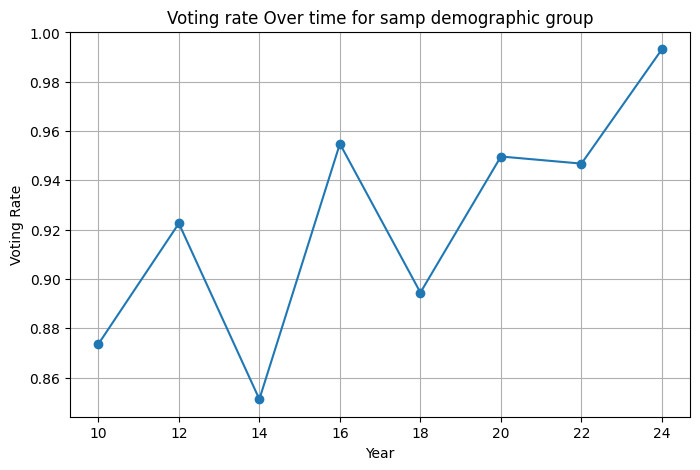

In [40]:
import matplotlib.pyplot as plt
# this is a test of the group id 
# looking at demographic group region 1, masters and above, 55-64 years old, high income

plt.figure(figsize=(8,5))
plt.plot(group_ts["year"], group_ts["did_vote_1"], marker="o")
plt.title("Voting rate Over time for samp demographic group")
plt.xlabel("Year")
plt.ylabel("Voting Rate")
plt.grid(True)
plt.show()

In [45]:
# tracking the group ids over time to see if they are consistent
group_counts = data.groupby("group_id").size().reset_index(name='count')
# sorting by count to see which groups are most common
group_counts = group_counts.sort_values(by='count', ascending=False)
#print(group_counts.head(50))

# group survival rate (we have a group id that persists over all 7 years)
group_survival = (
    data.groupby("group_id")["year"]
    .nunique()
    .reset_index(name='year_count')
)
# percentage of groups that survive all 7 years
num_full_groups = (group_survival["year_count"] == 8).sum()
total_groups = len(group_survival)

percentage = num_full_groups / total_groups

print(percentage)

1.0


In [42]:
# why is there such a high count of groups that only appear in one year??
one_year_groups = group_survival[group_survival["year_count"] == 1]["group_id"]
one_year_data = data[data["group_id"].isin(one_year_groups)]
year_counts = one_year_data["year"].value_counts().sort_index()
print(year_counts)

Series([], Name: count, dtype: int64)


In [43]:
# problematic year is 2014 
df_14 = data[data["year"] == 14]
df_12 = data[data["year"] == 12]
set(df_14["education_grouped"]) - set(df_12["education_grouped"])
cols = ["education_grouped", "age_group", "family_income_grouped", "geo_region"]

for col in cols:
    diff = set(df_14[col]) - set(df_12[col])
    print(f"{col}: {diff}")

education_grouped: set()
age_group: set()
family_income_grouped: set()
geo_region: set()


In [6]:
#df_14["geo_region"].value_counts()
# soemthing super weird going on in 2014 with the regions 

# reading in the 2014 data to see if there is just an issue in the aggregation 
raw_14 = pd.read_csv("clean_data/years/nov14pub_clean.csv")
# value counts of the geo region in the raw data
print(raw_14["GEDIV"].value_counts())

# all of the regions in 2014 are 0, so either need to remove geographic region from the grouping or use states, or skip 2014 entirely

GEDIV
0    80292
Name: count, dtype: int64


# Testing building the architecture for the LSTM


In [46]:
# another look at where the weights are zero in the full dataset
weight_zero_df = data[data['weight'] == 0]
print(weight_zero_df.shape)

(268, 65)


In [47]:
# zero weights by years 
weight_zero_by_year = weight_zero_df['year'].value_counts().sort_index()
print(weight_zero_by_year)

year
10    43
12    38
14    25
16    34
18    24
20    38
22    35
24    31
Name: count, dtype: int64


In [50]:
# are the zero weights by years consistent groups or do they change?
zero_weight_groups = weight_zero_df['group_id'].unique()
zero_weight_group_counts = weight_zero_df.groupby('group_id')['year'].nunique().reset_index(name='year_count')

In [51]:
print(zero_weight_group_counts)

                                         group_id  year_count
0                   1_associates_18-24_low_income           3
1                   1_associates_35-44_low_income           1
2        1_less_than_highschool_25-34_high_income           5
3        1_less_than_highschool_35-44_high_income           3
4        1_less_than_highschool_45-54_high_income           1
..                                            ...         ...
96          9_masters_and_above_18-24_high_income           4
97           9_masters_and_above_18-24_low_income           4
98   9_masters_and_above_18-24_lower_middle_class           5
99         9_masters_and_above_18-24_middle_class           2
100          9_masters_and_above_25-34_low_income           2

[101 rows x 2 columns]


In [62]:
unique_missing_groups = zero_weight_group_counts.groupby('group_id').count() 
# missing groups that are missing in more than one year
missing_multiple_years = zero_weight_group_counts[zero_weight_group_counts['year_count'] > 1]
missing_multiple_years_count = missing_multiple_years.shape[0]
print(missing_multiple_years_count)

66


In [64]:
zero_weight_group_counts.groupby('year_count').size()

year_count
1    35
2    19
3    16
4    12
5    15
6     4
dtype: int64

# evaluating the stability of the LSTM cohort 

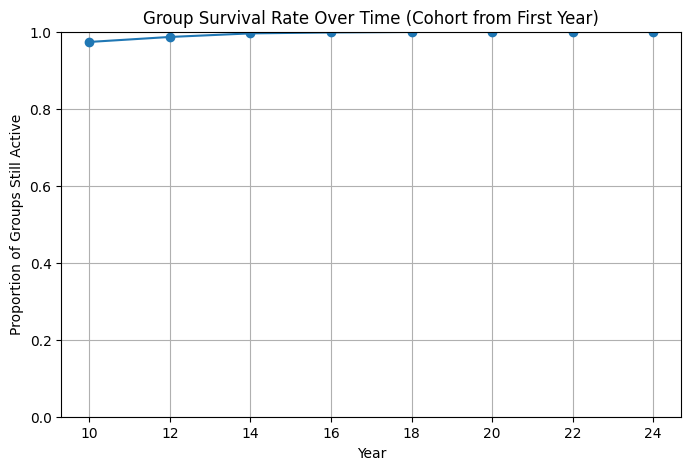

In [86]:
# a group is considered valid if the weight is greater than zero in all the years
first_year = data["year"].min()

# group ids that are present in the first year 
# we want total longevity where possible, so starting in the first year 
cohort_groups = set(
    data[data["year"] == first_year]["group_id"].unique()
)

cohort_df = data[data["group_id"].isin(cohort_groups)].copy()

# valid only if the weight is greater than 0 
cohort_df["valid"] = cohort_df["weight"] > 0

# groups are considered dead once the weight is zero in any year
cohort_df = cohort_df.sort_values(["group_id", "year"])

cohort_df["ever_valid"] = cohort_df.groupby("group_id")["valid"].cummax()

# alive
cohort_df["alive"] = cohort_df["ever_valid"]

# cohort survival rate over time
survival_by_year = (
    cohort_df.groupby("year")["alive"]
    .mean()
    .reset_index()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(survival_by_year["year"], survival_by_year["alive"], marker="o")
plt.title("Group Survival Rate Over Time (Cohort from First Year)")
plt.xlabel("Year")
plt.ylabel("Proportion of Groups Still Active")
plt.ylim(0,1)
plt.grid(True)
plt.show()

In [76]:
print(survival_by_year)

   year     alive
0    10  0.973457
1    12  0.986420
2    14  0.995679
3    16  0.998148
4    18  0.999383
5    20  1.000000
6    22  1.000000
7    24  1.000000


In [78]:
data.columns

Index(['geo_region', 'education_grouped', 'age_group', 'family_income_grouped',
       'year', 'weight', 'time_at_curr_address_-9', 'time_at_curr_address_-3',
       'time_at_curr_address_-2', 'time_at_curr_address_1',
       'time_at_curr_address_2', 'time_at_curr_address_3',
       'time_at_curr_address_4', 'time_at_curr_address_5',
       'time_at_curr_address_6', 'curr_student_-1', 'curr_student_1',
       'curr_student_2', 'lease_type_1', 'lease_type_2', 'lease_type_3',
       'marital_status_1', 'marital_status_2', 'marital_status_3',
       'marital_status_4', 'marital_status_5', 'marital_status_6',
       'job_industry_code_-1', 'job_industry_code_1', 'job_industry_code_2',
       'job_industry_code_3', 'job_industry_code_4', 'job_industry_code_5',
       'job_industry_code_6', 'job_industry_code_7', 'job_industry_code_8',
       'job_industry_code_9', 'job_industry_code_10', 'job_industry_code_11',
       'job_industry_code_12', 'job_industry_code_13', 'job_industry_code_14',


In [87]:
# define feature columns
non_feature_cols = ["geo_region", "education_grouped", "age_group", "family_income_grouped", "group_id", "year", "weight"]
feature_cols = [col for col in data.columns if col not in non_feature_cols]
data.groupby("year")[feature_cols].mean()


,time_at_curr_address_-9,time_at_curr_address_-3,time_at_curr_address_-2,time_at_curr_address_1,time_at_curr_address_2,time_at_curr_address_3,time_at_curr_address_4,time_at_curr_address_5,time_at_curr_address_6,curr_student_-1,...,sex_1,sex_2,race_grouped_PI_only,race_grouped_american_indian_only,race_grouped_asian_only,race_grouped_black_only,race_grouped_multiracial,race_grouped_white_only,did_vote_1,time_at_curr_address_-1
year,,,,,,,,,,,,,,,,,,,,,
10,0.001917,0.006615,0.004579,0.012169,0.086988,0.041884,0.134131,0.122825,0.562349,0.818519,...,0.459310,0.514147,0.001960,0.008597,0.031022,0.098100,0.014047,0.819731,0.533429,NaN
12,0.001235,0.006747,0.004979,0.012256,0.092739,0.038567,0.124599,0.121701,0.573719,0.822222,...,0.464353,0.512190,0.002417,0.010410,0.034981,0.106136,0.019306,0.803293,0.696646,NaN
14,NaN,NaN,NaN,0.145356,0.142425,0.118688,0.564729,NaN,NaN,0.331481,...,0.464843,0.519725,0.002397,0.012931,0.034947,0.109011,0.018203,0.807078,0.479709,0.013369
16,NaN,NaN,NaN,0.143338,0.138538,0.130591,0.551744,NaN,NaN,0.330247,...,0.465378,0.513634,0.002030,0.013788,0.038642,0.118267,0.020114,0.786172,0.689638,0.014802
18,NaN,NaN,NaN,0.137670,0.145863,0.139125,0.545500,NaN,NaN,0.332099,...,0.465264,0.519922,0.002637,0.013591,0.039923,0.118471,0.019097,0.791466,0.605823,0.017027
20,NaN,NaN,NaN,0.131831,0.145310,0.136242,0.548700,NaN,NaN,0.332099,...,0.467203,0.509341,0.004078,0.014127,0.042463,0.122077,0.019603,0.774196,0.744573,0.014461
22,NaN,NaN,NaN,0.127399,0.149366,0.141752,0.545945,NaN,NaN,0.333333,...,0.468440,0.509955,0.003260,0.012585,0.044767,0.124625,0.022044,0.771115,0.553577,0.013933
24,NaN,NaN,NaN,0.122248,0.132608,0.147663,0.563988,NaN,NaN,0.332099,...,0.457328,0.523536,0.003878,0.014576,0.043068,0.128685,0.023132,0.767525,0.692753,0.014357


In [90]:
# percentage alive over all the years 
final_year = data["year"].max()
group_survival = (
    cohort_df.groupby("group_id")
    .agg(all_years_valid=("valid", "min"))  # 1 only if never zero
)

full_survival_rate = group_survival["all_years_valid"].mean()

print(f"Full survival rate: {full_survival_rate:.2%}")

Full survival rate: 93.77%


In [92]:
print(group_survival)

                                       all_years_valid
group_id                                              
1_associates_18-24_high_income                    True
1_associates_18-24_low_income                    False
1_associates_18-24_lower_middle_class             True
1_associates_18-24_middle_class                   True
1_associates_18-24_upper_middle_class             True
...                                                ...
9_some_college_65+_high_income                    True
9_some_college_65+_low_income                     True
9_some_college_65+_lower_middle_class             True
9_some_college_65+_middle_class                   True
9_some_college_65+_upper_middle_class             True

[1620 rows x 1 columns]


In [81]:
# since we are aggregating, we should just fill the nas with 0 
data[feature_cols] = data[feature_cols].fillna(0)

In [88]:
data[feature_cols].isna().sum().sort_values(ascending=False)

time_at_curr_address_-9              9720
time_at_curr_address_5               9720
time_at_curr_address_-2              9720
time_at_curr_address_-3              9720
time_at_curr_address_6               9720
time_at_curr_address_-1              3240
time_at_curr_address_4                  0
time_at_curr_address_3                  0
job_industry_code_13                    0
job_industry_code_14                    0
job_industry_code_15                    0
job_industry_code_16                    0
job_industry_code_17                    0
job_industry_code_18                    0
job_industry_code_19                    0
job_industry_code_20                    0
job_industry_code_21                    0
job_industry_code_22                    0
job_industry_code_23                    0
GED_or_HS_-1                            0
GED_or_HS_1                             0
GED_or_HS_2                             0
sex_1                                   0
sex_2                             

# picking the groups for modeling 

In [101]:
# picking the groups that survived all the years for the modeling
surviving_groups = group_survival[group_survival["all_years_valid"] == 1].index

model_data = data[data["group_id"].isin(surviving_groups)].copy()

# sorting the dataframe

In [104]:
model_data = model_data.sort_values(["group_id", 'year'])

In [105]:
model_data.columns

Index(['geo_region', 'education_grouped', 'age_group', 'family_income_grouped',
       'year', 'weight', 'time_at_curr_address_-9', 'time_at_curr_address_-3',
       'time_at_curr_address_-2', 'time_at_curr_address_1',
       'time_at_curr_address_2', 'time_at_curr_address_3',
       'time_at_curr_address_4', 'time_at_curr_address_5',
       'time_at_curr_address_6', 'curr_student_-1', 'curr_student_1',
       'curr_student_2', 'lease_type_1', 'lease_type_2', 'lease_type_3',
       'marital_status_1', 'marital_status_2', 'marital_status_3',
       'marital_status_4', 'marital_status_5', 'marital_status_6',
       'job_industry_code_-1', 'job_industry_code_1', 'job_industry_code_2',
       'job_industry_code_3', 'job_industry_code_4', 'job_industry_code_5',
       'job_industry_code_6', 'job_industry_code_7', 'job_industry_code_8',
       'job_industry_code_9', 'job_industry_code_10', 'job_industry_code_11',
       'job_industry_code_12', 'job_industry_code_13', 'job_industry_code_14',


# defining our X dataframe

In [108]:
# x is group id, demographic features 
# y is voting rate (did_vote_1)
not_X_features = ['geo_region', 'education_grouped', 'age_group', 'family_income_grouped', 'did_vote_1', 'weight']
feature_cols = [
    c for c in model_data.columns
    if c not in ["group_id", "year", "did_vote_1"]
]
y = model_data['did_vote_1']

# build sequences 

In [109]:
X_seq = []
y_seq = []

for gid, g in model_data.groupby("group_id"):
    g = g.sort_values("year")

    X_seq.append(g[feature_cols].values)
    y_seq.append(g["did_vote_1"].values)

# pad sequences / masking 

In [3]:
pip install 'numpy>=2.0,<3.0'


  Using cached numpy-2.4.4-cp312-cp312-macosx_14_0_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp312-cp312-macosx_14_0_x86_64.whl (6.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.16.2 requires numpy<2.0.0,>=1.26.0; python_version >= "3.12", but you have numpy 2.4.4 which is incompatible.
numba 0.62.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

df = data.copy()

# -----------------------
# 1. Define target
# -----------------------
y = df["did_vote_1"]   # adjust if your positive class column differs

# -----------------------
# 2. Drop target + any leakage columns
# -----------------------
X = df.drop(columns=["did_vote_1", "did_vote_0"], errors="ignore")

# -----------------------
# 3. Identify categorical + numeric
# -----------------------
cat_cols = X.select_dtypes(include=["object", "category"]).columns
num_cols = X.columns.difference(cat_cols)

# -----------------------
# 4. Preprocessing
# -----------------------
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

# -----------------------
# 5. Model
# -----------------------
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

# -----------------------
# 6. Pipeline
# -----------------------
clf = Pipeline([
    ("prep", preprocess),
    ("model", model)
])

# -----------------------
# 7. Train/test split
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------
# 8. Fit
# -----------------------
clf.fit(X_train, y_train)

# -----------------------
# 9. Evaluate
# -----------------------
preds = clf.predict(X_test)
print("R^2:", r2_score(y_test, preds))

R^2: 0.6960525286787511
